Mount Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

 1741188570941.jpg
 1741454490399.png
'AI-Lab13 (1).docx'
'AI-Lab13 (2).docx'
'AI-Lab13 (3).docx'
 AI-Lab13.docx
 archive.zip
'Assignment 02 Applied Physics (1).gdoc'
'Assignment 02 Applied Physics (2).gdoc'
'Assignment 02 Applied Physics (3).gdoc'
'Assignment 02 Applied Physics.gdoc'
'Assignment 03 Applied Physics (1).gdoc'
'Assignment 03 Applied Physics (2).gdoc'
'Assignment 03 Applied Physics (3).gdoc'
'Assignment 03 Applied Physics.gdoc'
'Assignment 04 Applied Physics (1).gdoc'
'Assignment 04 Applied Physics.gdoc'
 Assignment-3-OOP-Spring-2025.gdoc
'BSc (Hons) Computer Science III (Batch 2024).xlsx'
'C++ for Everyone (1).gdoc'
'C++ for Everyone.gdoc'
 Classroom
'COAL Lab 13 (1).gdoc'
'COAL Lab 13.gdoc'
 COAL-LAB3-PART5.gdoc
'Colab Notebooks'
 DB-LABWEEK13-MAKEUP-PART1.docx
 Discrete_Mathematics_and_Its_Applications_7th_Edition_Rosen.gdoc
'Discriptive Statistics.gslides'
'Expository writing (SDG3).gdoc'
 F2024-0506-B-LAB-9.ipynb
'F2024-0506 (URWA AHMAD).docx'
'Fill this template for

Unzip Dataset

In [10]:
!find "/content/drive/MyDrive" -iname "*archive*"

/content/drive/MyDrive/archive.zip


In [13]:
!find /content/drive/MyDrive -iname "*.zip"

/content/drive/MyDrive/Classroom/ICT Lab A A/lab_week1.zip
/content/drive/MyDrive/Classroom/Object Oriented Programming A/SSIGNMENT 7 CODE.zip
/content/drive/MyDrive/Classroom/LAB-220 | Data Structures Lab 1 | B F2024 - B/DSA Project Fourth Submission.zip
/content/drive/MyDrive/Classroom/LAB-220 | Data Structures Lab 1 | B F2024 - B/DSA-LAB10.zip
/content/drive/MyDrive/Classroom/Advanced Database Systems Lab Section B/Melodify_F2025-0800, F2024-0506.zip
/content/drive/MyDrive/Classroom/Mobile Computing A/Urwa Ahmad(F2024-0506).zip
/content/drive/MyDrive/Classroom/Mobile Computing A/UrwaAhmad-Assignment2_F2024-0506.zip
/content/drive/MyDrive/Classroom/Mobile Computing A/Urwa Ahmad_Assignment2_F2024-0506.zip.zip
/content/drive/MyDrive/Classroom/Mobile Computing A/Melodify (2).zip
/content/drive/MyDrive/Classroom/Mobile Computing A/Melodify (1).zip
/content/drive/MyDrive/Classroom/Mobile Computing A/Melodify.zip
/content/drive/MyDrive/Classroom/AI-Lab B/F2024_0506_B_Assignment2.zip
/conte

In [12]:
!find /content/drive/MyDrive -iname "unified_dataset"

In [ ]:
!ls /content

dataset  drive	sample_data


In [ ]:
!find /content/dataset -maxdepth 3 -type d

/content/dataset
/content/dataset/content
/content/dataset/content/unified_dataset
/content/dataset/content/unified_dataset/textiles
/content/dataset/content/unified_dataset/metal
/content/dataset/content/unified_dataset/trash
/content/dataset/content/unified_dataset/organic_waste
/content/dataset/content/unified_dataset/glass
/content/dataset/content/unified_dataset/paper_cardboard
/content/dataset/content/unified_dataset/plastic
/content/dataset/content/unified_dataset/battery


In [14]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [20]:
!ls /content/dataset

content


In [21]:
!ls /content/dataset/content

unified_dataset


load dataset

In [17]:
dataset_path = "/content/dataset/content/unified_dataset"

dataset = datasets.ImageFolder(
    dataset_path,
    transform=train_transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['battery', 'glass', 'metal', 'organic_waste', 'paper_cardboard', 'plastic', 'textiles', 'trash']
Total Images: 64000


Verify GPU

In [22]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


Dataset Structure

In [19]:
import os

dataset_path = "/content/dataset/content/unified_dataset"

total = 0

for cls in sorted(os.listdir(dataset_path)):
    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total += count
        print(f"{cls}: {count}")

print("\nTotal Images:", total)

battery: 8000
glass: 8000
metal: 8000
organic_waste: 8000
paper_cardboard: 8000
plastic: 8000
textiles: 8000
trash: 8000

Total Images: 64000


Import Libraries

In [23]:
!pip install -q torch torchvision

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision.models import resnet101

from torch.utils.data import DataLoader
from torch.utils.data import random_split

import numpy as np
import os

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


Data Augmentation

In [26]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

Load Dataset

In [27]:
dataset_path = "/content/dataset/content/unified_dataset"

dataset = datasets.ImageFolder(
    dataset_path,
    transform=train_transform
)

print("Number of classes:", len(dataset.classes))
print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Number of classes: 8
Classes: ['battery', 'glass', 'metal', 'organic_waste', 'paper_cardboard', 'plastic', 'textiles', 'trash']
Total Images: 64000


Train / Validation / Test Split


In [28]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform


print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

Training Images: 44800
Validation Images: 9600
Testing Images: 9600


DataLoader

In [29]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 700
Validation batches: 150
Test batches: 150


Verify DataLoader

In [30]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


Verify Classes

In [ ]:
print(dataset.classes)

['battery', 'glass', 'metal', 'organic_waste', 'paper_cardboard', 'plastic', 'textiles', 'trash']


Load ResNet Model

In [31]:
import torch
import torch.nn as nn

from torchvision.models import resnet101

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet101(weights="IMAGENET1K_V1")

model.fc = nn.Linear(
    model.fc.in_features,
    8
)

model = model.to(device)

print("Model Loaded Successfully")
print("Using Device:", device)

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 131MB/s]


Model Loaded Successfully
Using Device: cuda


Loss + Optimizer

In [32]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

print("Optimizer Ready")

Optimizer Ready


Learning Rate Scheduler

In [33]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Scheduler Ready")

Scheduler Ready


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Training

In [34]:
epochs = 10

best_acc = 0

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_acc = 100 * correct / total

    scheduler.step(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/best_resnet101.pth"
        )

        print("Best Model Saved")

Epoch 1/10 | Train Acc: 90.48% | Val Acc: 93.96%
Best Model Saved
Epoch 2/10 | Train Acc: 96.60% | Val Acc: 95.52%
Best Model Saved
Epoch 3/10 | Train Acc: 97.58% | Val Acc: 95.67%
Best Model Saved
Epoch 4/10 | Train Acc: 98.01% | Val Acc: 95.41%
Epoch 5/10 | Train Acc: 98.38% | Val Acc: 96.23%
Best Model Saved
Epoch 6/10 | Train Acc: 98.58% | Val Acc: 95.07%
Epoch 7/10 | Train Acc: 98.65% | Val Acc: 96.72%
Best Model Saved
Epoch 8/10 | Train Acc: 98.90% | Val Acc: 96.20%
Epoch 9/10 | Train Acc: 99.00% | Val Acc: 95.45%
Epoch 10/10 | Train Acc: 99.03% | Val Acc: 97.16%
Best Model Saved


In [35]:
print("Best Validation Accuracy:", best_acc)

Best Validation Accuracy: 97.15625


Load Best Saved Model

In [39]:
import torch
import torch.nn as nn
from torchvision.models import resnet101

model = resnet101(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    8
)

model.load_state_dict(
    torch.load(
        "/content/best_resnet101.pth"
    )
)

model = model.to(device)

model.eval()

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


Test Accuracy

In [40]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 96.76%


Confusion Matrix

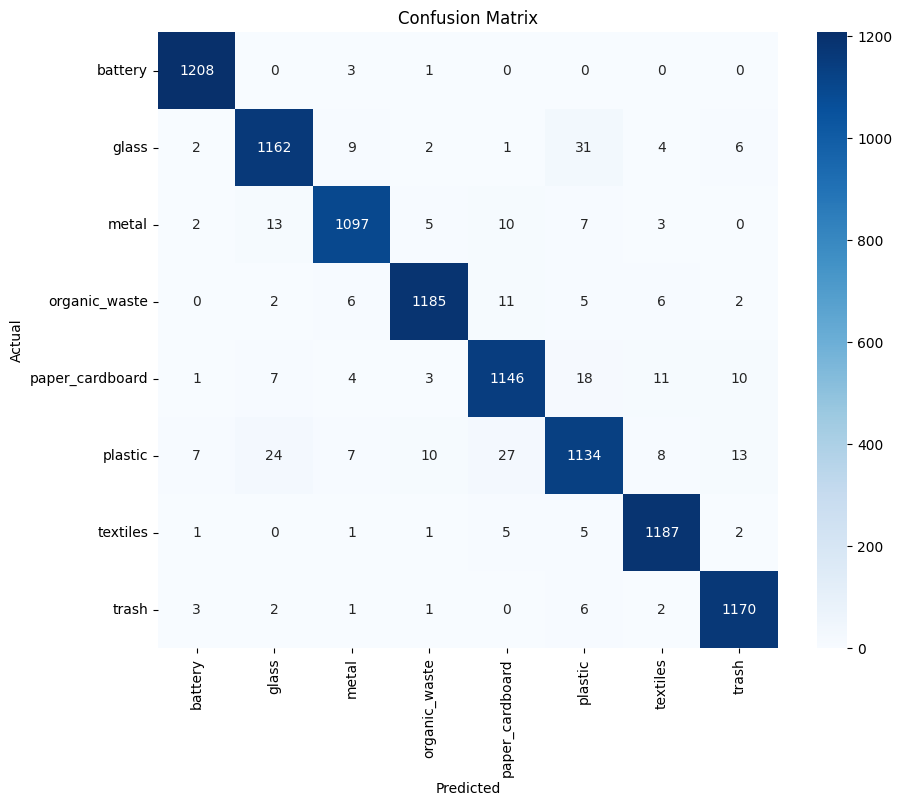

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Classification Report

In [42]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

                 precision    recall  f1-score   support

        battery       0.99      1.00      0.99      1212
          glass       0.96      0.95      0.96      1217
          metal       0.97      0.96      0.97      1137
  organic_waste       0.98      0.97      0.98      1217
paper_cardboard       0.95      0.95      0.95      1200
        plastic       0.94      0.92      0.93      1230
       textiles       0.97      0.99      0.98      1202
          trash       0.97      0.99      0.98      1185

       accuracy                           0.97      9600
      macro avg       0.97      0.97      0.97      9600
   weighted avg       0.97      0.97      0.97      9600



Upload Any Image

In [46]:
from google.colab import files

uploaded = files.upload()

Saving image.png to image.png


Prediction

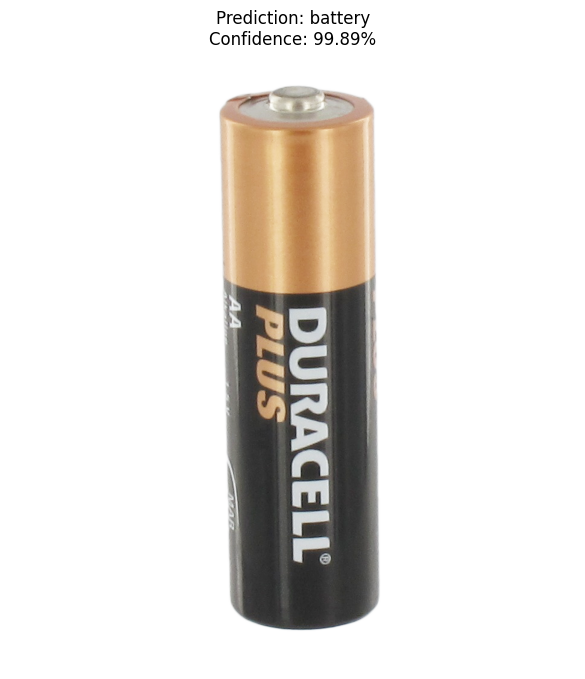

Predicted Class: battery
Confidence: 99.89%


In [48]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

image_path = list(uploaded.keys())[0]

img = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

img_tensor = transform(img)
img_tensor = img_tensor.unsqueeze(0)
img_tensor = img_tensor.to(device)

model.eval()

with torch.no_grad():

    outputs = model(img_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    confidence, predicted = torch.max(
        probabilities,
        1
    )

predicted_class = dataset.classes[
    predicted.item()
]

confidence_score = confidence.item() * 100

plt.figure(figsize=(8,8))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence_score:.2f}%"
)

plt.axis("off")

plt.show()

print(
    f"Predicted Class: {predicted_class}"
)

print(
    f"Confidence: {confidence_score:.2f}%"
)